# Localización de dispositivos mediante señales Wi-Fi

**Autor:** Rafael Alejandro Hernandez Falla

**Universidad EAN**

**Programa:** Ingenieria en Sistemas

## Descripción

Este proyecto analiza mediciones de intensidad de señal recibida, RSSI, provenientes de siete puntos de acceso Wi-Fi. El propósito es identificar patrones en las señales y construir un modelo que permita estimar en cuál de cuatro habitaciones se encuentra un dispositivo.

## Pregunta de análisis

¿Es posible determinar la ubicación de un dispositivo dentro de un espacio cerrado utilizando la intensidad de las señales recibidas desde diferentes puntos de acceso Wi-Fi?

## Objetivo general

Analizar las mediciones RSSI de siete puntos de acceso y desarrollar un modelo de clasificación que permita estimar la ubicación de un dispositivo en una de cuatro habitaciones.

## 1. Carga del conjunto de datos

Se utilizará el conjunto de datos Wireless Indoor Localization del repositorio UCI. Este contiene 2.000 observaciones de intensidad de señal Wi-Fi tomadas desde siete puntos de acceso. Cada observación está asociada con una de cuatro habitaciones.

**Fuente:** UCI Machine Learning Repository, Wireless Indoor Localization.  
https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization


In [105]:
## Aqui importamos el archivo y lo convertimos
## en un DataFrame
import pandas as pd
columnas = [
    "AP1", "AP2","AP3","AP4","AP5","AP6","AP7", "Habitacion"
]
datos = pd.read_csv(
    "/content/wifi_localization.txt",
    names=columnas,
    sep="\t",
    header=None
)

In [106]:
## Con este comando verificamos que el DataFrame
## se haya creado correctamente (.head nos muestra solamente las primeras 5 filas)
datos.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Habitacion
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


In [107]:
## Con "shape" nos muestra la cantidad de filas y columnas de
## nuestro dataframe
datos.shape

(2000, 8)

## 2. Inspección y limpieza de los datos

Antes de realizar el análisis, se revisan los tipos de datos, los valores faltantes y los registros duplicados. Esto permite determinar si el conjunto de datos necesita algún proceso de limpieza.

In [108]:
## El "info" Nos muestra el numero de filas, nombres de las
## columnas, cantidad de valores no nulos, tipo de dato de
## cada columna
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   AP1         2000 non-null   int64
 1   AP2         2000 non-null   int64
 2   AP3         2000 non-null   int64
 3   AP4         2000 non-null   int64
 4   AP5         2000 non-null   int64
 5   AP6         2000 non-null   int64
 6   AP7         2000 non-null   int64
 7   Habitacion  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [109]:
## "isnull" pregunta si cada valor esta vacio y se complementa con "sum"
## que cuenta los valores vacios de cada columna
datos.isnull().sum()

,0
AP1,0
AP2,0
AP3,0
AP4,0
AP5,0
AP6,0
AP7,0
Habitacion,0


In [110]:
## Con "Duplicated" va a identificar filas completamente repetidas
## y "sum" las va a contar
datos.duplicated().sum()

np.int64(0)

In [111]:
## Aunque no hay problemas con los datos, vamos a trabajar con una
## copia de los datos originales por buena practica
datos_limpios = datos.copy()

## 3. Análisis estadístico descriptivo

Se calculan medidas de tendencia central y dispersión para comprender el comportamiento de la intensidad de señal recibida desde cada punto de acceso.

In [112]:
## No incluimos habitación ya que entra como una categoria, no una medicion
columnas_AP = ["AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7"]

In [113]:
## Aqui creamos una tabla que calcula: La media, cuartiles,
## desviacion, etc
datos_limpios[columnas_AP].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AP1,2000.0,-52.33,11.32,-74.0,-61.0,-55.0,-46.0,-10.0
AP2,2000.0,-55.62,3.42,-74.0,-58.0,-56.0,-53.0,-45.0
AP3,2000.0,-54.96,5.32,-73.0,-58.0,-55.0,-51.0,-40.0
AP4,2000.0,-53.57,11.47,-77.0,-63.0,-56.0,-46.0,-11.0
AP5,2000.0,-62.64,9.11,-89.0,-69.0,-64.0,-56.0,-36.0
AP6,2000.0,-80.98,6.52,-97.0,-86.0,-82.0,-77.0,-61.0
AP7,2000.0,-81.73,6.52,-98.0,-87.0,-83.0,-78.0,-63.0


In [114]:
## Ahora si una tabla que incluya parametros estadisticos generales
estadisticas = pd.DataFrame({
    "Media": datos_limpios[columnas_AP].mean(),
    "Mediana": datos_limpios[columnas_AP].median(),
    "Moda": datos_limpios[columnas_AP].mode().iloc[0],
    "Mínimo": datos_limpios[columnas_AP].min(),
    "Máximo": datos_limpios[columnas_AP].max(),
    "Rango": (
        datos_limpios[columnas_AP].max()
        - datos_limpios[columnas_AP].min()
    ),
    "Varianza": datos_limpios[columnas_AP].var(),
    "Desviación estándar": datos_limpios[columnas_AP].std()
}).round(2)

estadisticas

,Media,Mediana,Moda,Mínimo,Máximo,Rango,Varianza,Desviación estándar
AP1,-52.33,-55.0,-59.0,-74,-10,64,128.18,11.32
AP2,-55.62,-56.0,-56.0,-74,-45,29,11.68,3.42
AP3,-54.96,-55.0,-56.0,-73,-40,33,28.26,5.32
AP4,-53.57,-56.0,-59.0,-77,-11,66,131.61,11.47
AP5,-62.64,-64.0,-64.0,-89,-36,53,82.90,9.11
AP6,-80.98,-82.0,-87.0,-97,-61,36,42.47,6.52
AP7,-81.73,-83.0,-85.0,-98,-63,35,42.51,6.52


In [115]:
## Identificamos cual es el AP con mayor y menor intesidad promedio
ap_mas = estadisticas["Media"].idxmax()
ap_menos = estadisticas["Media"].idxmin()
print(f"El AP con la mayor intensidad promedio es: {ap_mas}")
print(f"El AP con la menor intensidad promedio es: {ap_menos}")

El AP con la mayor intensidad promedio es: AP1
El AP con la menor intensidad promedio es: AP7


### Comparación de señales por habitación

Los promedios generales no permiten observar las diferencias espaciales. Por esta razón, se calcula la intensidad promedio de cada punto de acceso dentro de cada habitación.

In [116]:
promedios_habitacion = (
    datos_limpios
    .groupby("Habitacion")[columnas_AP]
    .mean()
    .round(2)
)

promedios_habitacion

,AP1,AP2,AP3,AP4,AP5,AP6,AP7
Habitacion,,,,,,,
1,-62.49,-56.28,-60.52,-64.18,-70.26,-82.92,-84.03
2,-36.92,-56.11,-55.90,-38.07,-67.61,-72.64,-73.50
3,-49.73,-54.89,-52.78,-50.70,-63.23,-81.37,-82.39
4,-60.18,-55.22,-50.65,-61.32,-49.45,-87.01,-86.99


In [117]:
## Verificamos cual AP recibe la señal mas fuerte por habitacion
promedios_habitacion.idxmax(axis=1)

,0
Habitacion,
1,AP2
2,AP1
3,AP1
4,AP5


In [118]:
## Verificamos lo mismo que arriba, solo que mas especifico
for habitacion in promedios_habitacion.index:
    ap = promedios_habitacion.loc[habitacion].idxmax()
    valor = promedios_habitacion.loc[habitacion].max()
    print(
        f"Habitación {habitacion}: "
        f"señal más fuerte en {ap} con {valor} dBm"
    )

Habitación 1: señal más fuerte en AP2 con -56.28 dBm
Habitación 2: señal más fuerte en AP1 con -36.92 dBm
Habitación 3: señal más fuerte en AP1 con -49.73 dBm
Habitación 4: señal más fuerte en AP5 con -49.45 dBm


### Intensidad promedio de señal por habitación

Se utiliza un mapa de calor para visualizar cómo cambia la intensidad promedio de cada señal Wi-Fi entre las cuatro habitaciones. Los valores menos negativos representan señales más fuertes.

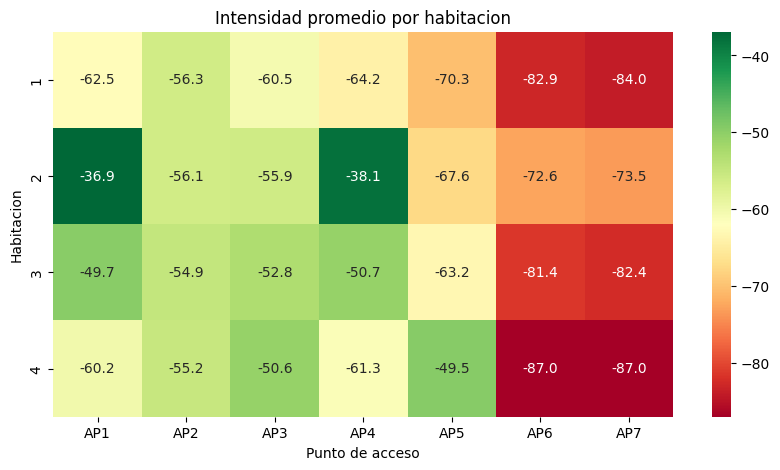

In [119]:
## Importamos las herramientas graficas
import matplotlib.pyplot as plt
import seaborn as sns
## Creamos el mapa de calor
plt.figure(figsize=(10, 5))
sns.heatmap(
    promedios_habitacion,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)
plt.title("Intensidad promedio por habitacion")
plt.xlabel("Punto de acceso")
plt.ylabel("Habitacion")
plt.show()

El mapa de calor muestra que cada habitación posee un patrón particular de intensidad de señal. La habitación 2 se caracteriza por valores altos en AP1 y AP4, mientras que AP5 tiene una presencia especialmente fuerte en la habitación 4. Aunque las habitaciones 1 y 3 presentan patrones similares, las señales AP1 y AP4 son más intensas en la habitación 3. Esto indica que la combinación de las siete señales puede utilizarse como una huella Wi-Fi para diferenciar las ubicaciones.

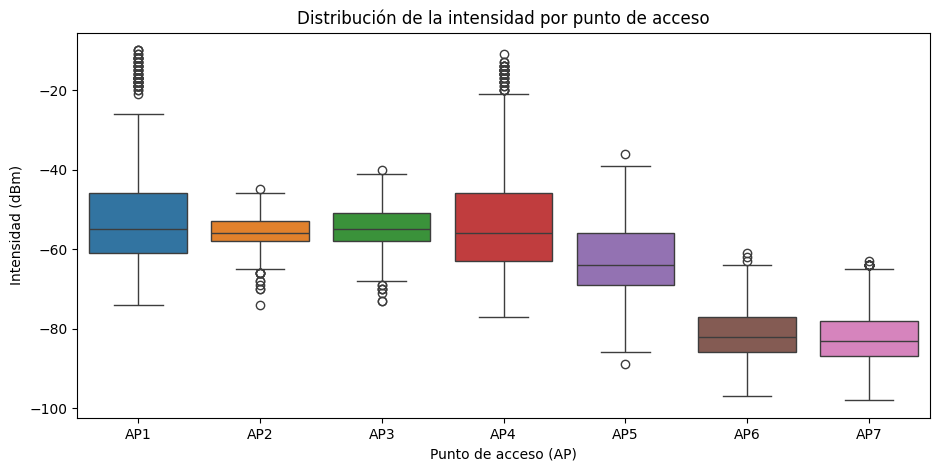

In [120]:
## Ahora voy a crear un diagrama de cajas para identificar valor atipicos u outliders
plt.figure(figsize=(11, 5))

sns.boxplot(data=datos_limpios[columnas_AP])

plt.title("Distribución de la intensidad por punto de acceso")
plt.xlabel("Punto de acceso (AP)")
plt.ylabel("Intensidad (dBm)")
plt.show()

In [121]:
## Usamos el metodo del rango intercualifico para cuantificar valores atipicos
q1 = datos_limpios[columnas_AP].quantile(0.25)
q3 = datos_limpios[columnas_AP].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

cantidad_ati = (
    (datos_limpios[columnas_AP] < limite_inf)
    | (datos_limpios[columnas_AP] > limite_sup)
).sum()
cantidad_ati

,0
AP1,59
AP2,12
AP3,9
AP4,41
AP5,2
AP6,3
AP7,14


In [122]:
## Convertimos los resultados anteriores para poder visualizarlos
## como tabla
resumen_atipicos = pd.DataFrame({
    "Límite inferior": limite_inf,
    "Límite superior": limite_sup,
    "Cantidad de atípicos": cantidad_ati
}).round(2)
resumen_atipicos

,Límite inferior,Límite superior,Cantidad de atípicos
AP1,-83.5,-23.5,59
AP2,-65.5,-45.5,12
AP3,-68.5,-40.5,9
AP4,-88.5,-20.5,41
AP5,-88.5,-36.5,2
AP6,-99.5,-63.5,3
AP7,-100.5,-64.5,14


Se identificaron valores potencialmente atípicos mediante el método del rango intercuartílico. Estos registros se conservaron porque las variaciones extremas de RSSI pueden estar relacionadas con la proximidad entre el dispositivo y los puntos de acceso. En este contexto, pueden representar información espacial relevante y no necesariamente errores de medición.

### Correlación entre puntos de acceso

Se analiza la correlación para determinar si las intensidades recibidas desde distintos puntos de acceso presentan comportamientos relacionados.

In [123]:
correlaciones = datos_limpios[columnas_AP].corr()

correlaciones.round(2)

,AP1,AP2,AP3,AP4,AP5,AP6,AP7
AP1,1.00,-0.00,0.05,0.92,-0.24,0.72,0.69
AP2,-0.00,1.00,0.28,0.01,0.20,0.07,0.05
AP3,0.05,0.28,1.00,0.08,0.62,-0.09,-0.07
AP4,0.92,0.01,0.08,1.00,-0.24,0.71,0.67
AP5,-0.24,0.20,0.62,-0.24,1.00,-0.42,-0.36
AP6,0.72,0.07,-0.09,0.71,-0.42,1.00,0.72
AP7,0.69,0.05,-0.07,0.67,-0.36,0.72,1.00


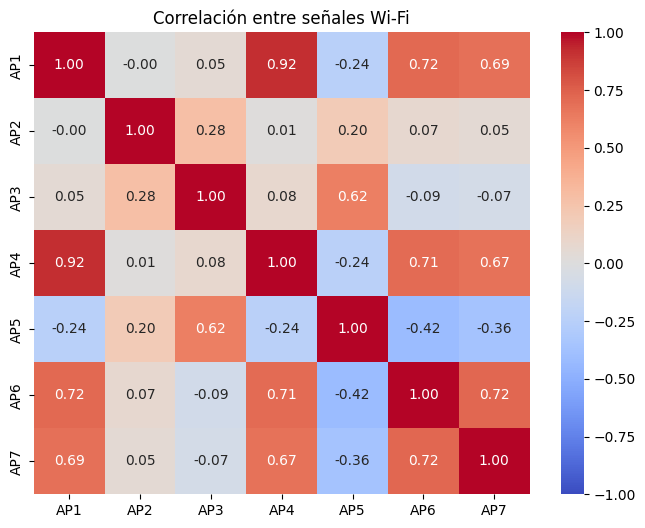

In [124]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre señales Wi-Fi")
plt.show()

La relación positiva más fuerte se encontró entre AP1 y AP4, con una correlación de 0,92. Esto indica que ambas señales presentan un comportamiento muy similar. La relación negativa más destacada fue de −0,42 entre AP5 y AP6, lo que sugiere que cuando una de estas señales aumenta, la otra tiende a disminuir. Estas relaciones contribuyen a formar patrones de señal diferentes para cada ubicación.

## 4. Construcción y evaluación del modelo

Debido a que la variable objetivo corresponde a una de cuatro habitaciones, se utiliza un modelo de clasificación mediante árbol de decisión. El conjunto de datos se divide en 80 % para entrenamiento y 20 % para evaluación.

In [125]:
## Separamos las señales Wi-Fi de la habitacion que queremos predecir
## Luego dividimos los datos: 80 % para entrenamiento y 20 % para prueba
X = datos_limpios[columnas_AP]
y = datos_limpios["Habitacion"]
from sklearn.model_selection import train_test_split
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X entrenamiento:", X_entrenamiento.shape)
print("X prueba:", X_prueba.shape)
print("y entrenamiento:", y_entrenamiento.shape)
print("y prueba:", y_prueba.shape)

X entrenamiento: (1600, 7)
X prueba: (400, 7)
y entrenamiento: (1600,)
y prueba: (400,)


In [126]:
## Creamos un arbol de decisión para clasificar las habitaciones
## Limitamos su profundidad para evitar un modelo demasiado complejo
from sklearn.tree import DecisionTreeClassifier
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo.fit(X_entrenamiento, y_entrenamiento)
print("Profundidad del árbol:", modelo.get_depth())
print("Cantidad de hojas:", modelo.get_n_leaves())

Profundidad del árbol: 4
Cantidad de hojas: 13


In [127]:
## Usamos el modelo entrenado para predecir los datos de prueba
## Después comparamos las habitaciones reales con las predichas
predicciones = modelo.predict(X_prueba)
comparacion = pd.DataFrame({
    "Habitación real": y_prueba.values,
    "Habitación predicha": predicciones
})

comparacion.head(10)

,Habitación real,Habitación predicha
0,4,4
1,2,2
2,1,1
3,3,3
4,4,4
5,3,3
6,1,1
7,1,1
8,2,2
9,1,1


In [128]:
## Importamos las métricas necesarias para evaluar el modelo
from sklearn.metrics import accuracy_score, confusion_matrix

## Calculamos la exactitud para conocer el porcentaje total de aciertos
exactitud = accuracy_score(y_prueba, predicciones)

print(f"Exactitud del modelo: {exactitud:.2%}")

Exactitud del modelo: 97.50%


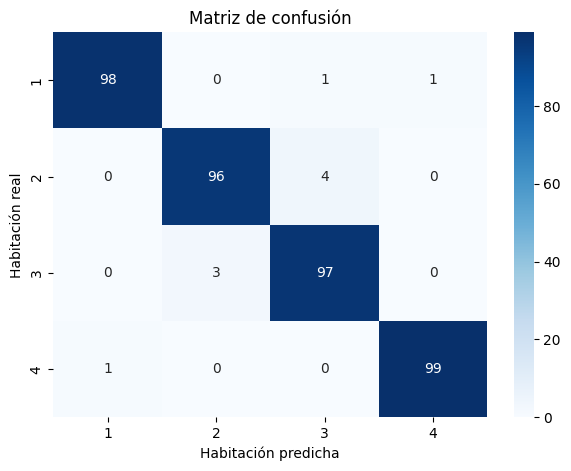

In [129]:
## Creamos una matriz de confusión para visualizar los aciertos y errores
## Los valores de la diagonal representan las predicciones correctas
matriz = confusion_matrix(y_prueba, predicciones)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4],
    yticklabels=[1, 2, 3, 4]
)

plt.title("Matriz de confusión")
plt.xlabel("Habitación predicha")
plt.ylabel("Habitación real")
plt.show()

In [130]:
## Contamos cuántas predicciones fueron correctas y cuántas fueron incorrectas
aciertos = (predicciones == y_prueba).sum()
errores = (predicciones != y_prueba).sum()

print("Predicciones correctas:", aciertos)
print("Predicciones incorrectas:", errores)
print(f"Exactitud: {exactitud:.2%}")

Predicciones correctas: 390
Predicciones incorrectas: 10
Exactitud: 97.50%


El modelo fue evaluado con 400 observaciones que no se utilizaron durante el entrenamiento. De estas, clasificó correctamente 390 registros y se equivocó en 10, alcanzando una exactitud de 97,50 %. La matriz de confusión muestra que la mayoría de los resultados se concentra en la diagonal, lo que indica un buen desempeño para diferenciar las cuatro habitaciones.

In [131]:
## Calculamos cuáles señales fueron más importantes para las decisiones del árbol
importancias = pd.Series(
    modelo.feature_importances_,
    index=columnas_AP
).sort_values(ascending=False)

importancias.round(3)

,0
AP1,0.586
AP5,0.370
AP4,0.041
AP3,0.002
AP6,0.001
AP2,0.000
AP7,0.000


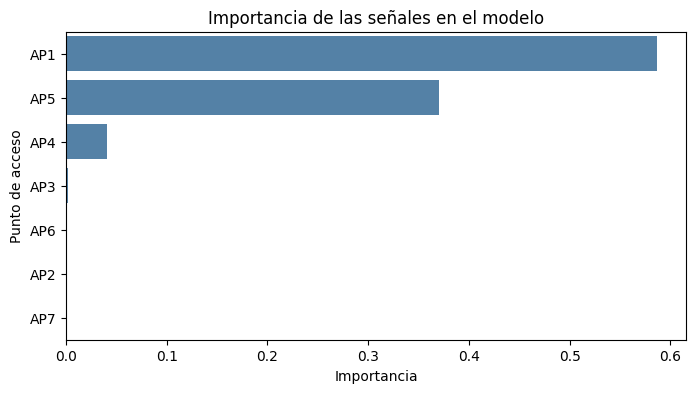

In [132]:
## Graficamos la importancia de cada punto de acceso
## Una barra más grande indica una mayor participación en las decisiones
plt.figure(figsize=(8, 4))

sns.barplot(
    x=importancias.values,
    y=importancias.index,
    color="steelblue"
)

plt.title("Importancia de las señales en el modelo")
plt.xlabel("Importancia")
plt.ylabel("Punto de acceso")
plt.show()

AP1 y AP5 fueron las variables más importantes para el modelo. AP1 permitió diferenciar principalmente las habitaciones 2 y 3, mientras que AP5 fue especialmente relevante para reconocer la habitación 4. AP4 tuvo una importancia menor y presenta una correlación alta con AP1, por lo que posiblemente proporciona información parcialmente redundante. El árbol consiguió clasificar las habitaciones utilizando principalmente una combinación reducida de señales.

## 5. Conclusiones

- Las mediciones RSSI forman patrones diferentes según la ubicación del dispositivo. Estos patrones pueden utilizarse como una huella Wi-Fi para distinguir espacios interiores.

- AP1 y AP5 fueron las señales más relevantes para la clasificación. AP1 presentó un comportamiento característico en las habitaciones 2 y 3, mientras que AP5 permitió reconocer principalmente la habitación 4.

- El árbol de decisión alcanzó una exactitud del 97,50 % sobre 400 observaciones de prueba. Clasificó correctamente 390 registros y cometió 10 errores.

- Los resultados demuestran que es posible estimar la habitación de un dispositivo utilizando únicamente intensidades de señales Wi-Fi, sin depender de GPS.

## Aplicación profesional

Este enfoque podría utilizarse como base para localizar activos, analizar cobertura inalámbrica, automatizar espacios interiores o apoyar sistemas de navegación dentro de edificios.

## Limitaciones

- El modelo fue entrenado con mediciones de un único entorno.
- No se conoce la ubicación física de los puntos de acceso.
- Los obstáculos, interferencias, dispositivos y cambios en la infraestructura pueden modificar los valores RSSI.
- Para utilizarlo en otro edificio sería necesario recopilar nuevas mediciones y volver a entrenar el modelo.

## Trabajo futuro

Se podría ampliar el proyecto tomando mediciones en diferentes edificios, utilizando más ubicaciones y comparando otros modelos de clasificación.